# Análise de Dependência: O Impacto das Estrelas nas Seleções

### Fonte dos dados
Fjelstul World Cup Database: histórico completo de todas as 
Copas de 1930 a 2022, com 27 datasets cobrindo gols, aparições 
e resultados.
Limitação: dados de aparições disponíveis apenas a partir 
de 1970.

### Metodologia
A estrela de cada seleção por Copa foi definida como o jogador 
com mais gols. O índice de dependência é a 
diferença de aproveitamento (win rate) com e sem esse jogador 
em campo.

### Objetivo Geral:
Entender o quanto uma seleção realmente depende da sua estrela.

In [61]:
import pandas as pd

In [62]:
df_goals = pd.read_csv('goals.csv')
df_matches = pd.read_csv('matches.csv')
df_player_appearances = pd.read_csv('player_appearances.csv')

Como é possível notar a tabela Player Appearances, se inicia com dados a partir de 1970, por isso devemos trazer os dados para se iniciar a partir deste mesmo ano. 

In [63]:
df_matches = df_matches[df_matches['match_date'] >= "1970-01-01"]
df_goals = df_goals[df_goals['match_date'] >= "1970-01-01"]

Precisamos definir o ano de cada partida, para isso vamos criar a coluna YEAR

In [64]:
df_goals ['match_date']= pd.to_datetime(df_goals['match_date'])
df_goals['year'] = df_goals['match_date'].dt.year
df_goals[['year', 'match_date']].head()

df_player_appearances ['match_date']= pd.to_datetime(df_player_appearances['match_date'])
df_player_appearances['year'] = df_player_appearances['match_date'].dt.year
df_player_appearances[['year', 'match_date']].head()

,year,match_date
0,1970,1970-05-31
1,1970,1970-05-31
2,1970,1970-05-31
3,1970,1970-05-31
4,1970,1970-05-31


In [65]:
df_goals = df_goals.groupby(['team_id', 'year', 'player_id']).size().reset_index(name='total_goals')
df_goals.head()

,team_id,year,player_id,total_goals
0,T-01,1982,P-40338,2
1,T-01,1982,P-45774,1
2,T-01,1982,P-59774,1
3,T-01,1982,P-68346,1
4,T-01,1986,P-42885,1


In [66]:
idx = df_goals.groupby(['team_id', 'year'])['total_goals'].idxmax()
estrelas = df_goals.loc[idx]
estrelas.head()

,team_id,year,player_id,total_goals
0,T-01,1982,P-40338,2
4,T-01,1986,P-42885,1
8,T-01,2014,P-59147,2
10,T-02,2006,P-78483,1
11,T-03,1974,P-04739,3


In [67]:
estrela_play = estrelas.merge(df_player_appearances, on=['team_id', 'year', 'player_id'], how='left')
estrela_play.head()

,team_id,year,player_id,total_goals,key_id,tournament_id,tournament_name,match_id,match_name,match_date,...,team_code,home_team,away_team,family_name,given_name,shirt_number,position_name,position_code,starter,substitute
0,T-01,1982,P-40338,2,2862.0,WC-1982,1982 FIFA Men's World Cup,M-1982-07,West Germany vs Algeria,1982-06-16,...,DZA,0.0,1.0,Assad,Salah,7.0,forward,FW,1.0,0.0
1,T-01,1982,P-40338,2,3223.0,WC-1982,1982 FIFA Men's World Cup,M-1982-22,Algeria vs Austria,1982-06-21,...,DZA,1.0,0.0,Assad,Salah,7.0,forward,FW,1.0,0.0
2,T-01,1982,P-40338,2,3451.0,WC-1982,1982 FIFA Men's World Cup,M-1982-31,Algeria vs Chile,1982-06-24,...,DZA,1.0,0.0,Assad,Salah,7.0,forward,FW,1.0,0.0
3,T-01,1986,P-42885,1,4191.0,WC-1986,1986 FIFA Men's World Cup,M-1986-08,Algeria vs Northern Ireland,1986-06-03,...,DZA,1.0,0.0,Zidane,Djamel,14.0,midfielder,MF,1.0,0.0
4,T-01,1986,P-42885,1,4442.0,WC-1986,1986 FIFA Men's World Cup,M-1986-17,Brazil vs Algeria,1986-06-06,...,DZA,0.0,1.0,Zidane,Djamel,14.0,midfielder,MF,0.0,1.0


In [68]:
df_estrela_win = estrela_play.merge(df_matches[['match_id', 'home_team_id','away_team_id', 'home_team_win', 'away_team_win', 'draw']], on=['match_id'], how='left')
df_estrela_win.head()

,team_id,year,player_id,total_goals,key_id,tournament_id,tournament_name,match_id,match_name,match_date,...,shirt_number,position_name,position_code,starter,substitute,home_team_id,away_team_id,home_team_win,away_team_win,draw
0,T-01,1982,P-40338,2,2862.0,WC-1982,1982 FIFA Men's World Cup,M-1982-07,West Germany vs Algeria,1982-06-16,...,7.0,forward,FW,1.0,0.0,T-86,T-01,0.0,1.0,0.0
1,T-01,1982,P-40338,2,3223.0,WC-1982,1982 FIFA Men's World Cup,M-1982-22,Algeria vs Austria,1982-06-21,...,7.0,forward,FW,1.0,0.0,T-01,T-05,0.0,1.0,0.0
2,T-01,1982,P-40338,2,3451.0,WC-1982,1982 FIFA Men's World Cup,M-1982-31,Algeria vs Chile,1982-06-24,...,7.0,forward,FW,1.0,0.0,T-01,T-13,1.0,0.0,0.0
3,T-01,1986,P-42885,1,4191.0,WC-1986,1986 FIFA Men's World Cup,M-1986-08,Algeria vs Northern Ireland,1986-06-03,...,14.0,midfielder,MF,1.0,0.0,T-01,T-52,0.0,0.0,1.0
4,T-01,1986,P-42885,1,4442.0,WC-1986,1986 FIFA Men's World Cup,M-1986-17,Brazil vs Algeria,1986-06-06,...,14.0,midfielder,MF,0.0,1.0,T-09,T-01,1.0,0.0,0.0


In [69]:
df_estrela_win['ganhou'] = (df_estrela_win['team_id'] == df_estrela_win['home_team_id']) & (df_estrela_win['home_team_win'] == 1) | (df_estrela_win['team_id'] == df_estrela_win['away_team_id']) & (df_estrela_win['away_team_win'] == 1)

In [70]:
df_estrela_win['ganhou'].value_counts()

ganhou
False    1052
True      803
Name: count, dtype: int64

In [71]:
# time da casa
home = df_matches[['match_id', 'home_team_id']].rename(columns={'home_team_id': 'team_id'})
  

# time visitante
away = df_matches[['match_id', 'away_team_id']].rename(columns={'away_team_id': 'team_id'})
  

# combinando os dois dataframes, cada jogo virou duas linhas por time
matches_teams = pd.concat([home, away], ignore_index=True)

matches_teams.head()

,match_id,team_id
0,M-1970-01,T-46
1,M-1970-02,T-84
2,M-1970-03,T-28
3,M-1970-04,T-56
4,M-1970-05,T-06


In [72]:
# Merge com indicator

df_todos = matches_teams.merge(estrela_play[['match_id', 'team_id']],
on=['match_id', 'team_id'],
how='left',
indicator=True)
# Filtra só os que não estão no estrela_play
df_sem_estrela = df_todos[df_todos['_merge'] == 'left_only']

In [73]:
# 1. Faz o merge com o df_matches para trazer de volta as colunas de validação do resultado
df_sem_estrela = df_sem_estrela.drop(columns=['home_team_id', 'away_team_id', 'home_team_win', 'away_team_win', 'draw'], errors='ignore') # Garante que não haverá duplicados se rodar mais de uma vez
df_sem_estrela = df_sem_estrela.merge(
    df_matches[['match_id', 'home_team_id', 'away_team_id', 'home_team_win', 'away_team_win', 'draw']], 
    on='match_id', 
    how='left'
)

# 2. Executa a lógica de checagem com os parênteses ajustados isolando cada cenário (Mandante e Visitante)
df_sem_estrela['ganhou'] = (
    (df_sem_estrela['team_id'] == df_sem_estrela['home_team_id']) & (df_sem_estrela['home_team_win'] == 1)
) | (
    (df_sem_estrela['team_id'] == df_sem_estrela['away_team_id']) & (df_sem_estrela['away_team_win'] == 1)
)

In [74]:
df_sem_estrela['ganhou'].value_counts()

ganhou
False    201
True      64
Name: count, dtype: int64

In [75]:
#Calculando indice de dependência
win_rate_estrela = df_estrela_win.groupby('team_id')['ganhou'].mean().reset_index(name='win_rate_estrela')

win_rate_sem_estrela = df_sem_estrela.groupby('team_id')['ganhou'].mean().reset_index(name='win_rate_sem_estrela')

dependencia = win_rate_estrela.merge(win_rate_sem_estrela, on='team_id', how='inner')
dependencia['indice'] = dependencia['win_rate_estrela'] - dependencia['win_rate_sem_estrela']
dependencia.head()

,team_id,win_rate_estrela,win_rate_sem_estrela,indice
0,T-01,0.333333,0.00,0.333333
1,T-02,0.000000,0.00,0.000000
2,T-03,0.571429,0.25,0.321429
3,T-04,0.222222,0.25,-0.027778
4,T-06,0.475000,0.60,-0.125000


In [76]:
dependencia.sort_values('indice', ascending=False).head(10)

,team_id,win_rate_estrela,win_rate_sem_estrela,indice
22,T-31,0.714286,0.2,0.514286
39,T-57,0.485714,0.0,0.485714
11,T-16,0.476190,0.0,0.476190
49,T-72,0.466667,0.0,0.466667
55,T-84,0.437500,0.0,0.437500
52,T-75,0.400000,0.0,0.400000
15,T-22,0.352941,0.0,0.352941
17,T-25,0.333333,0.0,0.333333
0,T-01,0.333333,0.0,0.333333
12,T-17,0.333333,0.0,0.333333


In [77]:
time_nomes = df_matches[['home_team_id', 'home_team_name']].drop_duplicates()
time_nomes.columns = ['team_id', 'team_name']
dependencia = dependencia.merge(time_nomes, how='left')
dependencia.sort_values('indice', ascending=False).head(10)

,team_id,win_rate_estrela,win_rate_sem_estrela,indice,team_name
22,T-31,0.714286,0.2,0.514286,Germany
39,T-57,0.485714,0.0,0.485714,Poland
11,T-16,0.476190,0.0,0.476190,Colombia
49,T-72,0.466667,0.0,0.466667,Soviet Union
55,T-84,0.437500,0.0,0.437500,Uruguay
52,T-75,0.400000,0.0,0.400000,Switzerland
15,T-22,0.352941,0.0,0.352941,Denmark
17,T-25,0.333333,0.0,0.333333,Ecuador
0,T-01,0.333333,0.0,0.333333,Algeria
12,T-17,0.333333,0.0,0.333333,Costa Rica


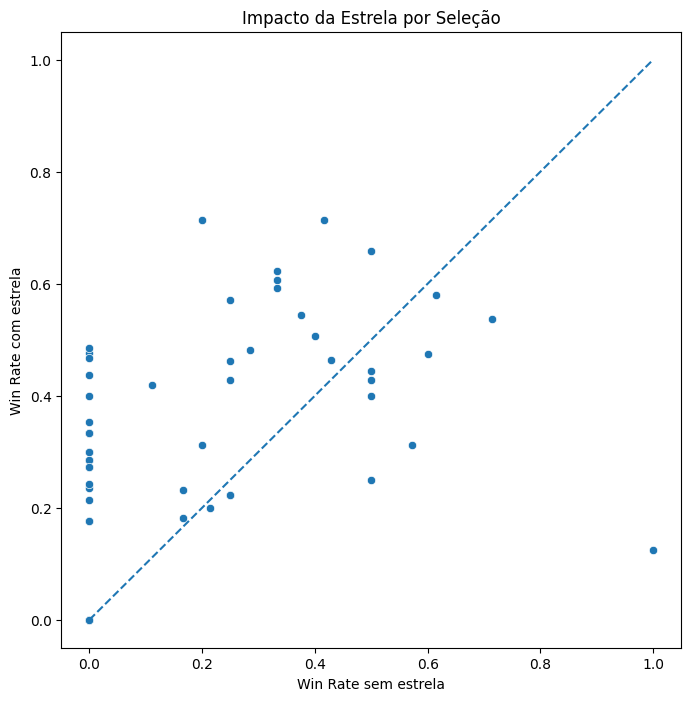

In [78]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=dependencia,
    x='win_rate_sem_estrela',
    y='win_rate_estrela'
)

plt.plot([0,1],[0,1], '--')

plt.xlabel('Win Rate sem estrela')
plt.ylabel('Win Rate com estrela')
plt.title('Impacto da Estrela por Seleção')

plt.show()

A maioria das seleções está posicionada acima da linha de equilíbrio, indicando que a presença do principal jogador tende a aumentar a taxa de vitórias.

Algumas equipes apresentam forte dependência da estrela, com diferenças significativas entre os dois cenários.

Casos abaixo da linha merecem investigação adicional, pois podem estar relacionados a amostras reduzidas ou características específicas do período analisado.

## Comparativo Messi vs CR7 vs Neymar 

In [79]:
#Preparação de dados geração moderna
df_player_appearances['given_name'] = df_player_appearances['given_name'].replace('not applicable', '')
df_player_appearances['player_name'] = df_player_appearances['given_name'] + ' ' + df_player_appearances['family_name']
df_player_appearances['player_name'] = df_player_appearances['player_name'].str.strip()

nomes = {'Neymar', 'Lionel Messi', 'Cristiano Ronaldo'}

estrelas_modernas = df_player_appearances[df_player_appearances['player_name'].isin(nomes)]
estrelas_modernas.value_counts('player_name')

player_name
Lionel Messi         26
Cristiano Ronaldo    22
Neymar               13
Name: count, dtype: int64

In [80]:
estrelas_modernas = estrelas_modernas.merge(df_matches[['match_id', 'home_team_id','away_team_id', 'home_team_win', 'away_team_win', 'draw']], on=['match_id'], how='left')
estrelas_modernas['ganhou'] = (estrelas_modernas['team_id'] == estrelas_modernas['home_team_id']) & (estrelas_modernas['home_team_win'] == 1) | (estrelas_modernas['team_id'] == estrelas_modernas['away_team_id']) & (estrelas_modernas['away_team_win'] == 1)
estrelas_modernas['ganhou'].value_counts()

ganhou
True     38
False    23
Name: count, dtype: int64

In [81]:
win_rate_estrelas_modernas = estrelas_modernas.groupby('player_name')['ganhou'].mean().reset_index(name='win_rate')

In [82]:
selecao_estrelas = {'T-09', 'T-03', 'T-58'}

df_selecoes = matches_teams[matches_teams['team_id'].isin(selecao_estrelas)]
df_selecoes.value_counts('team_id')


team_id
T-09    116
T-03     81
T-58     29
Name: count, dtype: int64

In [83]:
df_matches['match_date'] = pd.to_datetime(df_matches['match_date'])
df_matches['year'] = df_matches['match_date'].dt.year

In [84]:
# 1. Descobrir os anos em que cada jogador esteve presente em Copas do Mundo usando as estrelas modernas
anos_por_jogador = (
    estrelas_modernas.groupby(["player_id", "player_name"])["year"]
    .unique()
    .reset_index()
)

# 2. Replicar a base de jogos da seleção para CADA jogador correspondente usando o team_id
mapa_times = estrelas_modernas[
    ["player_id", "player_name", "team_id"]
].drop_duplicates()
base_periodo_jogador = mapa_times.merge(
    anos_por_jogador, on=["player_id", "player_name"]
)

# Explodir a lista de anos em linhas individuais para permitir o filtro por ano/time
base_periodo_jogador = base_periodo_jogador.explode("year")
base_periodo_jogador["year"] = base_periodo_jogador["year"].astype(int)

# CORREÇÃO DO KEYERROR: Como df_selecoes só tem match_id e team_id, trazemos o ano do df_matches
df_selecoes_ano = df_selecoes.merge(df_matches[["match_id", "match_date"]], on="match_id", how="left")
df_selecoes_ano["year"] = pd.to_datetime(df_selecoes_ano["match_date"]).dt.year

# 3. Trazer todos os jogos da seleção que aconteceram APENAS nos anos de Copa de cada jogador
jogos_no_periodo = df_selecoes_ano.merge(
    base_periodo_jogador, on=["team_id", "year"], how="inner"
)

jogos_no_periodo.head()

,match_id,team_id,match_date,year,player_id,player_name
0,M-2006-05,T-03,2006-06-10,2006,P-14758,Lionel Messi
1,M-2006-21,T-03,2006-06-16,2006,P-14758,Lionel Messi
2,M-2006-24,T-58,2006-06-17,2006,P-70442,Cristiano Ronaldo
3,M-2006-38,T-58,2006-06-21,2006,P-70442,Cristiano Ronaldo
4,M-2006-50,T-03,2006-06-24,2006,P-14758,Lionel Messi


In [85]:
# 4. Remover os jogos em que a estrela de fato entrou em campo (usando match_id e player_id)
df_todos_periodo = jogos_no_periodo.merge(
    estrelas_modernas[["match_id", "player_id"]],
    on=["match_id", "player_id"],
    how="left",
    indicator=True,
)

# Filtrar apenas as linhas onde o jogador NÃO atuou no período dele
sem_mordernas = df_todos_periodo[
    df_todos_periodo["_merge"] == "left_only"
].copy()
sem_mordernas = sem_mordernas.drop(columns=["_merge"])

# 5. Trazer o resultado do jogo (colunas de vitória) do df_matches
sem_mordernas = sem_mordernas.merge(
    df_matches[
        [
            "match_id",
            "home_team_id",
            "away_team_id",
            "home_team_win",
            "away_team_win",
        ]
    ],
    on="match_id",
    how="left",
)

# Aplica a lógica isolando os blocos (Mandante) | (Visitante) com parênteses
sem_mordernas["ganhou"] = (
    (sem_mordernas["team_id"] == sem_mordernas["home_team_id"])
    & (sem_mordernas["home_team_win"] == 1)
) | (
    (sem_mordernas["team_id"] == sem_mordernas["away_team_id"])
    & (sem_mordernas["away_team_win"] == 1)
)



In [86]:
# 1. Taxa de vitória de cada jogador COM ele em campo
win_rate_estrelas_modernas = (
    estrelas_modernas.groupby("player_name")["ganhou"]
    .mean()
    .reset_index(name="win_rate")
)

# 2. Taxa de vitória da seleção SEM eles no período correto de cada um
win_rate_sem_modernas = (
    sem_mordernas.groupby("player_name")["ganhou"]
    .mean()
    .reset_index(name="win_rate_sem_modernas")
)

# 3. Junta os dados de vitória COM e SEM o jogador
dependencia_morderna = win_rate_estrelas_modernas.merge(
    win_rate_sem_modernas, on="player_name", how="inner"
)

# 4. Calcula o índice de impacto real (Dependência) de cada craque
dependencia_morderna["indice"] = (
    dependencia_morderna["win_rate"]
    - dependencia_morderna["win_rate_sem_modernas"]
)

# Exibe o resultado final estruturado por jogador
dependencia_morderna[
    ["player_name", "win_rate", "win_rate_sem_modernas", "indice"]
]

,player_name,win_rate,win_rate_sem_modernas,indice
0,Cristiano Ronaldo,0.454545,1.00,-0.545455
1,Lionel Messi,0.730769,0.50,0.230769
2,Neymar,0.692308,0.25,0.442308


Na base de dados não houve partidas sem o CR7, por isso não vamos considera-lo para comparaçao

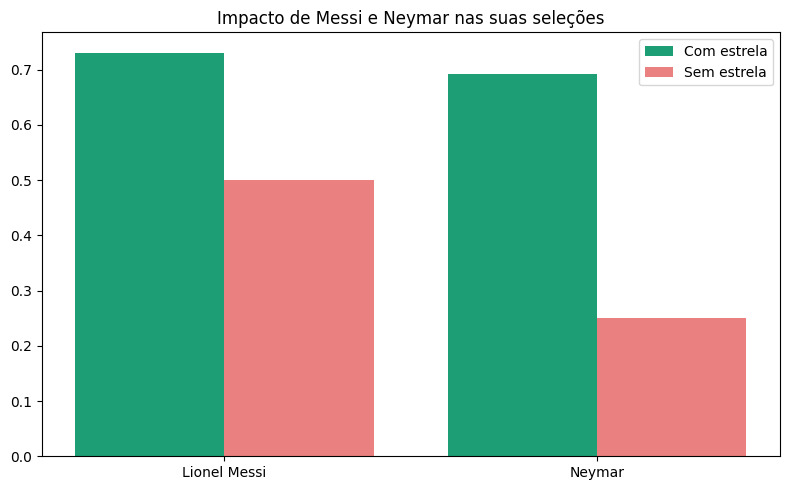

In [87]:
df_mod = dependencia_morderna[dependencia_morderna['player_name'] != 'Cristiano Ronaldo']
x = range(len(df_mod))
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - 0.2 for i in x], df_mod['win_rate'], width=0.4, label='Com estrela', color='#1D9E75')
ax.bar([i + 0.2 for i in x], df_mod['win_rate_sem_modernas'], width=0.4, label='Sem estrela', color='#E24B4A', alpha=0.7)
ax.set_xticks(list(x))
ax.set_xticklabels(df_mod['player_name'])
ax.set_title('Impacto de Messi e Neymar nas suas seleções')
ax.legend()
plt.tight_layout()
plt.show()

In [90]:
dependencia_morderna.to_csv('dependencia_moderna.csv', index=False)
dependencia.to_csv('dependencia.csv', index=False)
